In [2]:
import matplotlib.pyplot as plt
import numpy as np
from qutip import spin_Jx, spin_Jy, spin_Jz, spin_coherent
from scipy.optimize import minimize
from joblib import Parallel, delayed
import time as t
from scipy.linalg import sqrtm, inv, eigh, expm
import matplotlib.animation as animation
from IPython.display import HTML, display
from matplotlib import cm
import glob

In [6]:

# %%
def H(phi=[], beta=1, omega=1, J=1, w = []):
    phi = np.asarray(phi)
    cos_phi = np.cos(phi)[:, None, None]
    sin_phi = np.sin(phi)[:, None, None]
    return omega*(cos_phi*J_x + sin_phi*J_y) + beta/(2*J) * J_z2 + w[0]*J_x + w[1]*J_y + w[2]*J_z

rng = np.random.default_rng(3)
J = 4.5
dim = int(2*J+1)
t_steps = 14000
delta_t = 0.001
beta = 10
omega = 1
w_stdev = 0.1
w = rng.normal(0, w_stdev, size=3)
theta_scs = np.pi/2
phi_scs = 0
J_x = spin_Jx(J).full()
J_y = spin_Jy(J).full()
J_z = spin_Jz(J).full()
J_z2 = J_z @ J_z
obs_0 = J_z
control = True
# phi = 2*np.pi*rng.random(t_steps)
# in_state = spin_coherent(J, theta_scs, phi_scs, type = 'dm').full()


def commutator(A, B):
   """Compute the commutator [A, B] = AB - BA."""
   return A @ B - B @ A

def expect(obs, state):
    """Compute the expectation value of an observable."""
    return np.real(np.trace(obs @ state))

def repeated_random_array(total_len, repeat_n, low=0.0, high=1.0, phi_vals = None):
    if phi_vals is None:
        n_unique = int(np.ceil(total_len / repeat_n))
        vals = rng.uniform(low, high, size=n_unique)
    else:
        vals = phi_vals
    arr = np.repeat(vals, repeat_n)
    return arr[:total_len]

def bloch_vector(state_array):
    states = np.asarray(state_array)
    ex = np.einsum('ij,tji->t', J_x, states).real
    ey = np.einsum('ij,tji->t', J_y, states).real
    ez = np.einsum('ij,tji->t', J_z, states).real
    return (1/J) * np.stack([ex, ey, ez], axis=1)


def expectation_values(state_array, obs, steps=1):
    states = np.asarray(state_array)[::steps]
    return np.einsum('ij,tji->t', obs, states).real * (1/J)

In [9]:
beta_array = [0, 1, 5, 10, 50]
runs = len(beta_array)
num_phi_trials = 300  # set number of random phi realizations to average over
repeat_n = 1000
n_unique = int(np.ceil(t_steps / repeat_n))
block_idx = np.arange(t_steps) // repeat_n  # maps each timestep to its unique-phi block
n_expectation_steps = len(np.arange(0, t_steps + 1, 10))

norm_array_trials = np.zeros((num_phi_trials, runs, t_steps + 1))
mean_norm_array_trials = np.zeros((num_phi_trials, runs, t_steps + 1))
expectation_trials = np.zeros((num_phi_trials, runs, n_expectation_steps))

n_array = [None] * runs
mean_n_array = [None] * runs
expectation = [None] * runs
normalized_n_array = [None] * runs

# These don't depend on trial/beta, so compute them once instead of 50 times.
in_state = spin_coherent(J, theta_scs, phi_scs, type = 'dm').full()
H_w = w[0]*J_x + w[1]*J_y + w[2]*J_z
U_w = expm(-1j * delta_t * H_w)

for trial in range(num_phi_trials):
    # phi only ever takes n_unique distinct values (each repeated repeat_n times in a
    # row), so only n_unique Hamiltonians/propagators need to be exponentiated per run
    # instead of t_steps of them.
    phi_unique = rng.uniform(0.0, 2*np.pi, size=n_unique)
    for k in range(runs):
        beta = beta_array[k]

        if control:
            H_unique = H(phi_unique, beta, omega, J, w)
            U_unique = np.array([expm(-1j * delta_t * H_unique[j]) for j in range(n_unique)])
            A_unique = U_w @ U_unique  # combined per-step propagator U_w @ U, one per block

        state_array = [None] * (t_steps + 1)
        state = in_state
        state_array[0] = state
        for i in range(t_steps):
            if control:
                A = A_unique[block_idx[i]]
                state = A @ state @ A.conj().transpose()
            else:
                state = U_w @ state @ U_w.conj().transpose()
            state_array[i+1] = state

        #Calculate bloch vector norm
        n_array[k] = bloch_vector(state_array)
        norm_k = np.linalg.norm(n_array[k], axis=1)
        normalized_n_array[k] = n_array[k] / norm_k[:, None]
        mean_n_array[k] = np.cumsum(normalized_n_array[k], axis=0) / np.arange(1, len(normalized_n_array[k]) + 1)[:, None]
        mean_norm_k = np.linalg.norm(mean_n_array[k], axis=1)

        norm_array_trials[trial, k] = norm_k
        mean_norm_array_trials[trial, k] = mean_norm_k

        expectation[k] = expectation_values(state_array, obs_0, steps=10)
        expectation_trials[trial, k] = expectation[k]

# Average norm_array, mean_norm_array, and expectation over all random phi realizations.
# n_array, mean_n_array, and normalized_n_array hold the last trial's trajectories
# (used by the single-trajectory animation cells further down).
norm_array = list(norm_array_trials.mean(axis=0))
mean_norm_array = list(mean_norm_array_trials.mean(axis=0))
expectation = list(expectation_trials.mean(axis=0))

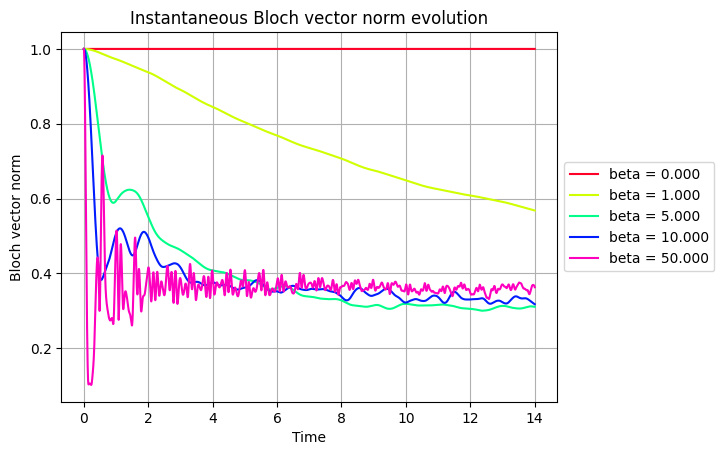

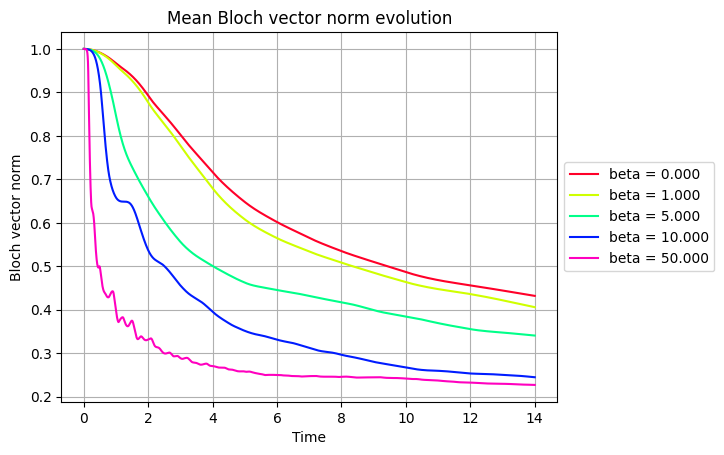

C:\Users\alexg\AppData\Local\Temp\ipykernel_33688\3510817189.py:24: RuntimeWarning: invalid value encountered in arccos
  theta_array[i] = np.arccos(mean_n_array[i][:, 2] / mean_norm_array[i])/np.pi


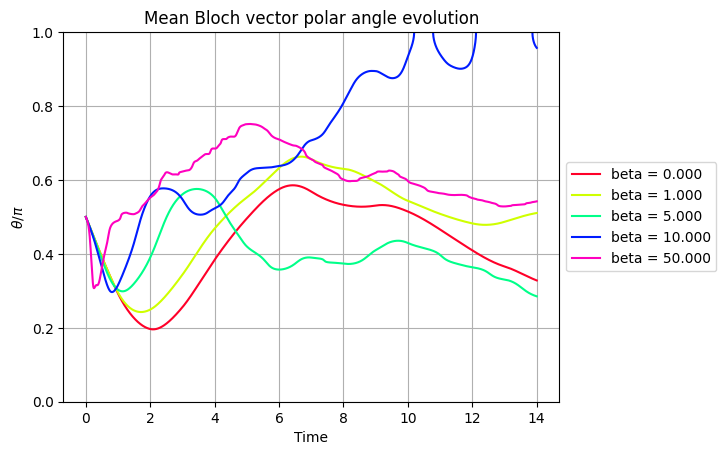

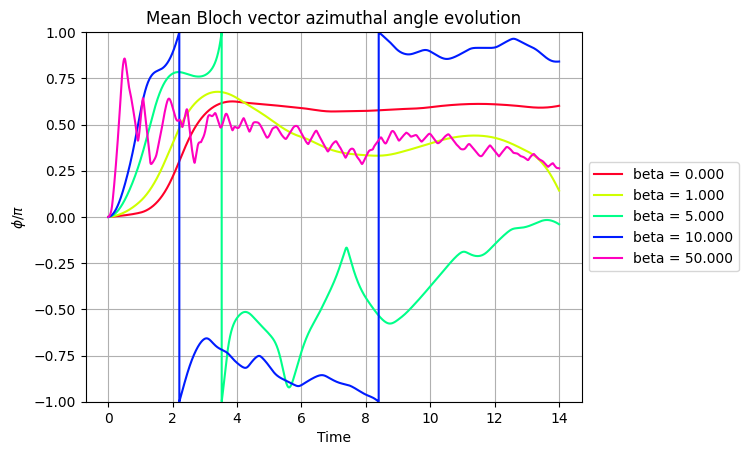

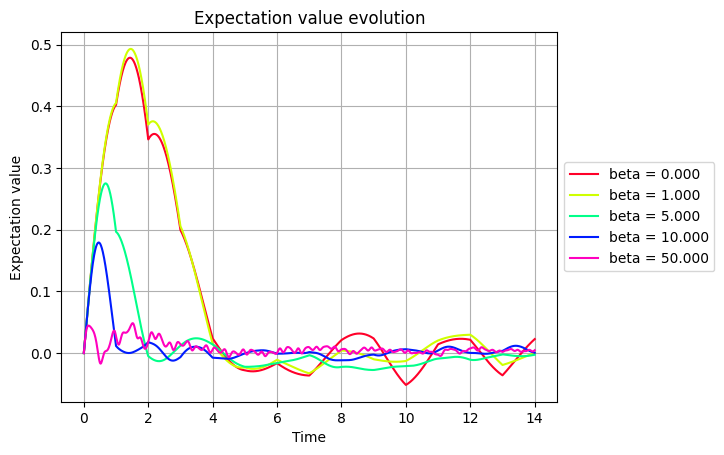

In [10]:
cmap = plt.cm.get_cmap('gist_rainbow', runs)
evolution_time = np.arange(0,t_steps+1) * delta_t
for i in range(runs):
    plt.plot(evolution_time, norm_array[i], label = f'beta = {beta_array[i]:.3f}', color = cmap(i))
plt.grid()
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.xlabel('Time')
plt.ylabel('Bloch vector norm')
plt.title('Instantaneous Bloch vector norm evolution')
plt.show()

for i in range(runs):
        plt.plot(evolution_time, mean_norm_array[i], label = f'beta = {beta_array[i]:.3f}', color = cmap(i))
plt.grid()
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.xlabel('Time')
plt.ylabel('Bloch vector norm')
plt.title('Mean Bloch vector norm evolution')
plt.show()

theta_array = [None] * runs
phi_array = [None] * runs
for i in range(runs):
    theta_array[i] = np.arccos(mean_n_array[i][:, 2] / mean_norm_array[i])/np.pi
    phi_array[i] = np.arctan2(mean_n_array[i][:, 1], mean_n_array[i][:, 0])/np.pi

for i in range(runs):
    plt.plot(evolution_time, theta_array[i], label = f'beta = {beta_array[i]:.3f}', color = cmap(i))
plt.grid()
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.xlabel('Time')
plt.ylabel(r'$\theta / \pi$')
plt.ylim(0, 1)
plt.title('Mean Bloch vector polar angle evolution')
plt.show()

for i in range(runs):
    plt.plot(evolution_time, phi_array[i], label = f'beta = {beta_array[i]:.3f}', color = cmap(i))
plt.grid()
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.xlabel('Time')
plt.ylabel(r'$\phi / \pi$')
plt.ylim(-1, 1)
plt.title('Mean Bloch vector azimuthal angle evolution')
plt.show()

for i in range(runs):
        plt.plot(evolution_time[::10], expectation[i], label = f'beta = {beta_array[i]:.3f}', color = cmap(i))
plt.grid()
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.xlabel('Time')
plt.ylabel('Expectation value')
plt.title('Expectation value evolution')
plt.show()

Instantaneous bloch vector evolution

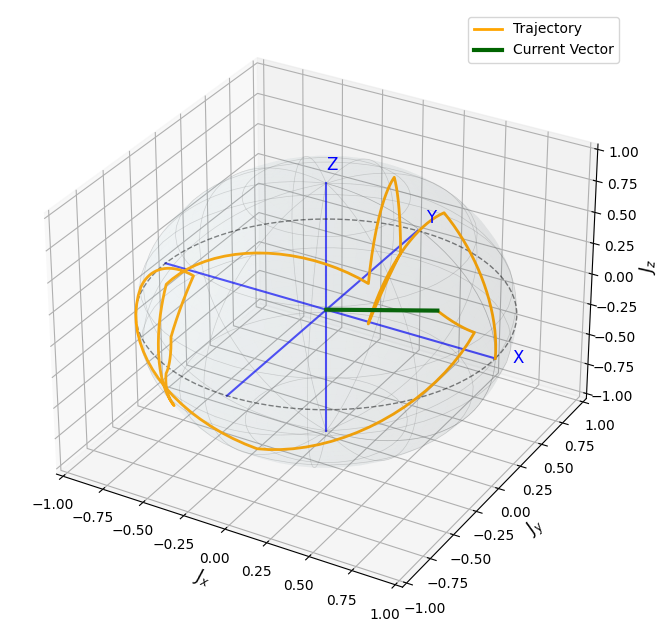

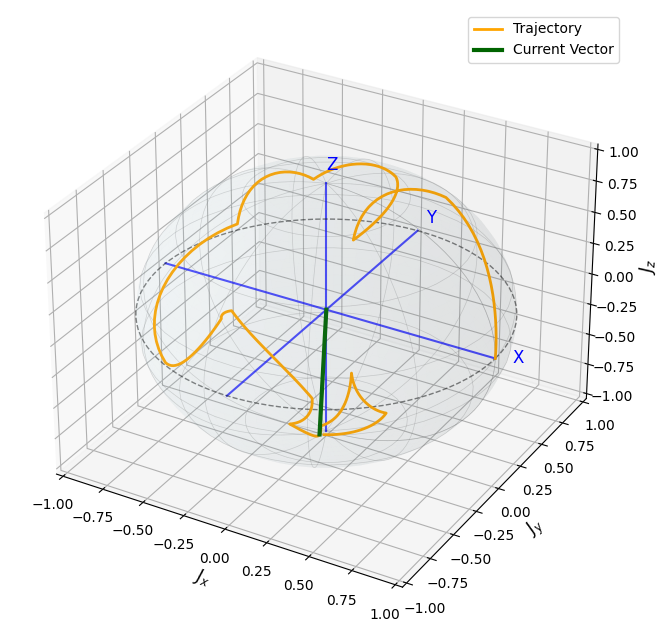

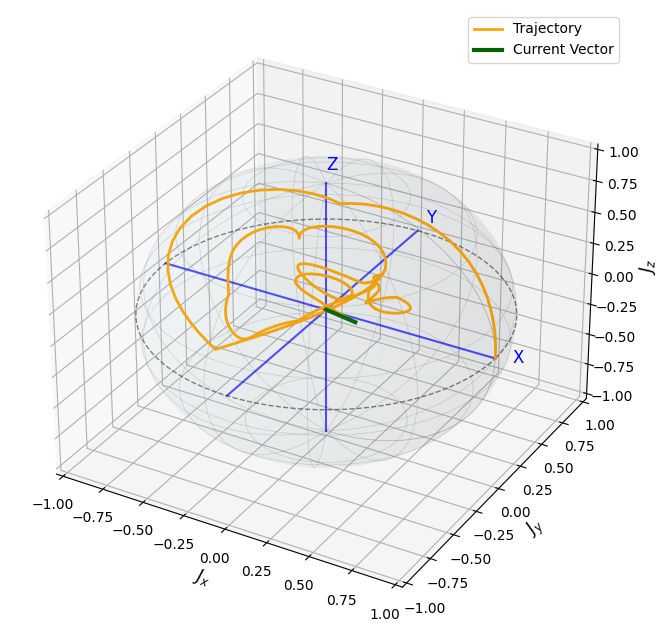

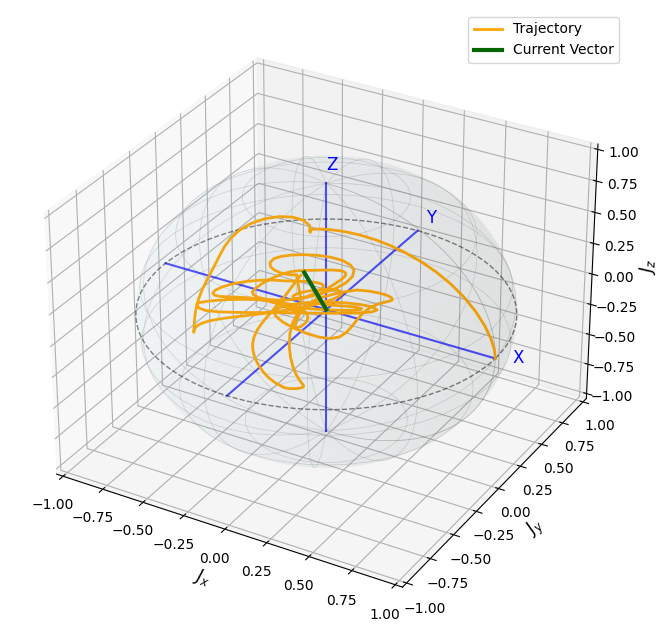

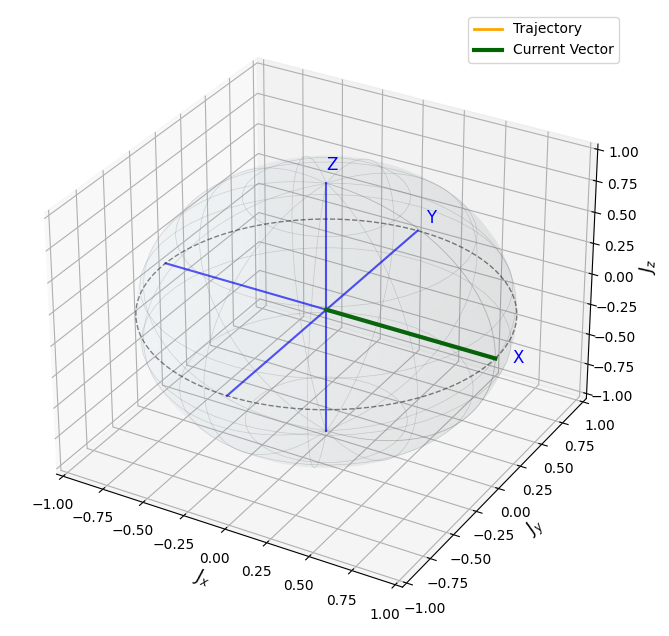

In [17]:
for i in range(runs):
    t = 50
    Jx = n_array[i][:,0][0::t]
    Jy = n_array[i][:,1][0::t]
    Jz = n_array[i][:,2][0::t]

    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(projection="3d")
    
    # Set axis limits and labels
    ax.set_xlim([-1, 1])
    ax.set_ylim([-1, 1])
    ax.set_zlim([-1, 1])
    ax.set_xlabel(r"$J_x$", fontsize=12)
    ax.set_ylabel(r"$J_y$", fontsize=12)
    ax.set_zlabel(r"$J_z$", fontsize=12)
    
    # Add a grid for better depth perception
    ax.grid(True, alpha=0.3)
    
    # Draw Bloch sphere with wireframe
    u = np.linspace(0, 2*np.pi, 50)
    v = np.linspace(0, np.pi, 50)
    xs = np.outer(np.cos(u), np.sin(v))
    ys = np.outer(np.sin(u), np.sin(v))
    zs = np.outer(np.ones_like(u), np.cos(v))
    
    # Draw sphere with low alpha and wireframe
    ax.plot_surface(xs, ys, zs, alpha=0.05, color='lightblue', linewidth=0, antialiased=True)
    
    # Add longitude lines (vertical great circles)
    for phi in np.linspace(0, 2*np.pi, 12):
        x = np.cos(phi) * np.sin(np.linspace(0, np.pi, 50))
        y = np.sin(phi) * np.sin(np.linspace(0, np.pi, 50))
        z = np.cos(np.linspace(0, np.pi, 50))
        ax.plot(x, y, z, color='gray', alpha=0.3, linewidth=0.5)
    
    # Add latitude lines (horizontal circles)
    for theta in np.linspace(0, np.pi, 8)[1:-1]:  # Skip poles
        r = np.sin(theta)
        z_val = np.cos(theta)
        phi = np.linspace(0, 2*np.pi, 50)
        x = r * np.cos(phi)
        y = r * np.sin(phi)
        z = np.ones_like(phi) * z_val
        ax.plot(x, y, z, color='gray', alpha=0.3, linewidth=0.5)
    
    # Draw coordinate axes with labels
    # X-axis (red)
    ax.plot([-1, 1], [0, 0], [0, 0], color='blue', alpha=0.7, linewidth=1.5)
    ax.text(1.1, 0, 0, 'X', color='blue', fontsize=12)
    
    # Y-axis (green)
    ax.plot([0, 0], [-1, 1], [0, 0], color='blue', alpha=0.7, linewidth=1.5)
    ax.text(0, 1.1, 0, 'Y', color='blue', fontsize=12)
    
    # Z-axis (blue)
    ax.plot([0, 0], [0, 0], [-1, 1], color='blue', alpha=0.7, linewidth=1.5)
    ax.text(0, 0, 1.1, 'Z', color='blue', fontsize=12)
    
    # Add poles
    #ax.scatter([0], [0], [1], color='black', s=20, alpha=0.8)
    #ax.scatter([0], [0], [-1], color='black', s=20, alpha=0.8)
    
    # Add equator line (special highlight)
    phi_eq = np.linspace(0, 2*np.pi, 100)
    x_eq = np.cos(phi_eq)
    y_eq = np.sin(phi_eq)
    z_eq = np.zeros_like(phi_eq)
    ax.plot(x_eq, y_eq, z_eq, color='black', alpha=0.5, linewidth=1, linestyle='--')
    
    # Trajectory + vector
    traj, = ax.plot([], [], [], lw=2, color='orange', label='Trajectory')
    vec, = ax.plot([], [], [], lw=3, color='darkgreen', label='Current Vector')
    
    # Add legend
    ax.legend(loc='upper right')
    
    def update(frame):
        traj.set_data(Jx[:frame], Jy[:frame])
        traj.set_3d_properties(Jz[:frame])
        vec.set_data([0, Jx[frame]], [0, Jy[frame]])
        vec.set_3d_properties([0, Jz[frame]])
        return traj, vec

    ani = animation.FuncAnimation(fig, update, frames=len(Jx), interval=40)
    if control:
        ani.save(f'instantaneous_bloch_vector_beta={beta_array[i]}_control.mp4', writer='ffmpeg', fps=30, dpi=100)
    else:
        ani.save(f'instantaneous_bloch_vector_w={w[0]:.2f}_{w[1]:.2f}_{w[2]:.2f}.mp4', writer='ffmpeg', fps=30, dpi=100)

Mean bloch vector evolution

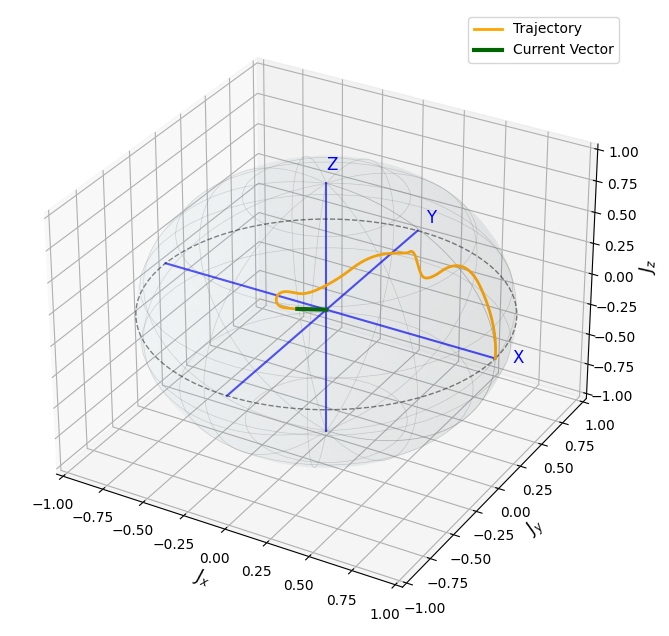

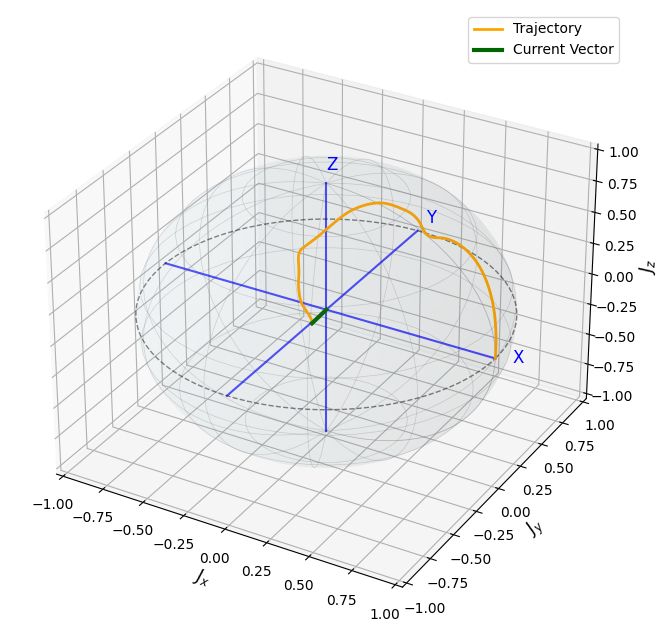

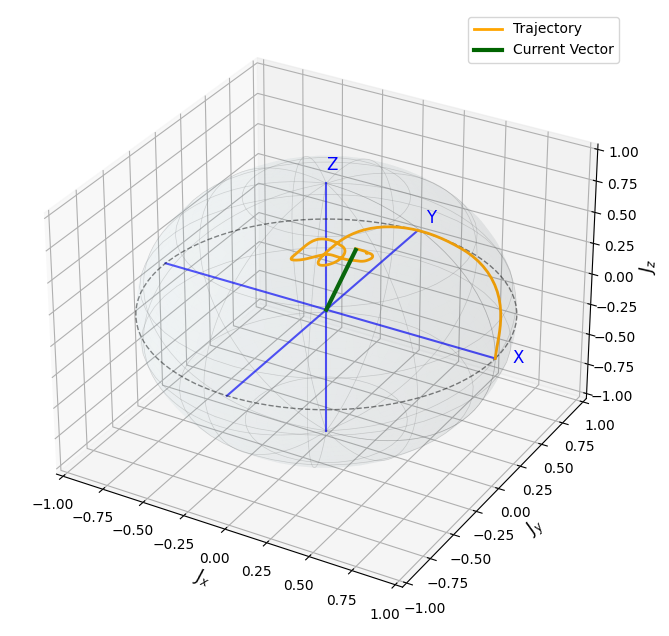

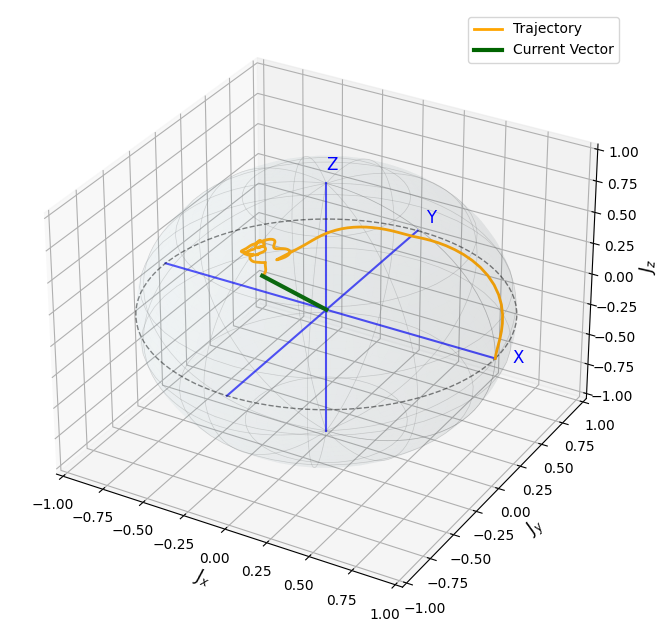

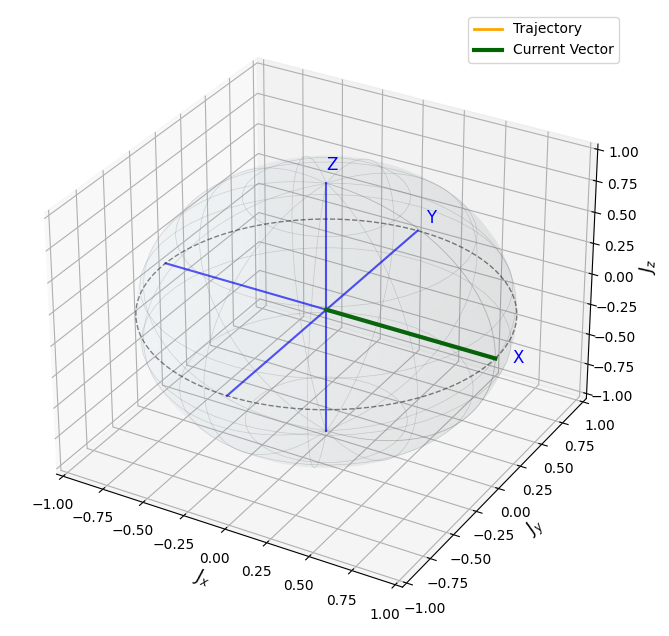

In [18]:
for i in range(runs):
    t = 50
    Jx = mean_n_array[i][:,0][0::t]
    Jy = mean_n_array[i][:,1][0::t]
    Jz = mean_n_array[i][:,2][0::t]

    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(projection="3d")
    
    # Set axis limits and labels
    ax.set_xlim([-1, 1])
    ax.set_ylim([-1, 1])
    ax.set_zlim([-1, 1])
    ax.set_xlabel(r"$J_x$", fontsize=12)
    ax.set_ylabel(r"$J_y$", fontsize=12)
    ax.set_zlabel(r"$J_z$", fontsize=12)
    
    # Add a grid for better depth perception
    ax.grid(True, alpha=0.3)
    
    # Draw Bloch sphere with wireframe
    u = np.linspace(0, 2*np.pi, 50)
    v = np.linspace(0, np.pi, 50)
    xs = np.outer(np.cos(u), np.sin(v))
    ys = np.outer(np.sin(u), np.sin(v))
    zs = np.outer(np.ones_like(u), np.cos(v))
    
    # Draw sphere with low alpha and wireframe
    ax.plot_surface(xs, ys, zs, alpha=0.05, color='lightblue', linewidth=0, antialiased=True)
    
    # Add longitude lines (vertical great circles)
    for phi in np.linspace(0, 2*np.pi, 12):
        x = np.cos(phi) * np.sin(np.linspace(0, np.pi, 50))
        y = np.sin(phi) * np.sin(np.linspace(0, np.pi, 50))
        z = np.cos(np.linspace(0, np.pi, 50))
        ax.plot(x, y, z, color='gray', alpha=0.3, linewidth=0.5)
    
    # Add latitude lines (horizontal circles)
    for theta in np.linspace(0, np.pi, 8)[1:-1]:  # Skip poles
        r = np.sin(theta)
        z_val = np.cos(theta)
        phi = np.linspace(0, 2*np.pi, 50)
        x = r * np.cos(phi)
        y = r * np.sin(phi)
        z = np.ones_like(phi) * z_val
        ax.plot(x, y, z, color='gray', alpha=0.3, linewidth=0.5)
    
    # Draw coordinate axes with labels
    # X-axis (red)
    ax.plot([-1, 1], [0, 0], [0, 0], color='blue', alpha=0.7, linewidth=1.5)
    ax.text(1.1, 0, 0, 'X', color='blue', fontsize=12)
    
    # Y-axis (green)
    ax.plot([0, 0], [-1, 1], [0, 0], color='blue', alpha=0.7, linewidth=1.5)
    ax.text(0, 1.1, 0, 'Y', color='blue', fontsize=12)
    
    # Z-axis (blue)
    ax.plot([0, 0], [0, 0], [-1, 1], color='blue', alpha=0.7, linewidth=1.5)
    ax.text(0, 0, 1.1, 'Z', color='blue', fontsize=12)
    
    # Add poles
    #ax.scatter([0], [0], [1], color='black', s=20, alpha=0.8)
    #ax.scatter([0], [0], [-1], color='black', s=20, alpha=0.8)
    
    # Add equator line (special highlight)
    phi_eq = np.linspace(0, 2*np.pi, 100)
    x_eq = np.cos(phi_eq)
    y_eq = np.sin(phi_eq)
    z_eq = np.zeros_like(phi_eq)
    ax.plot(x_eq, y_eq, z_eq, color='black', alpha=0.5, linewidth=1, linestyle='--')
    
    # Trajectory + vector
    traj, = ax.plot([], [], [], lw=2, color='orange', label='Trajectory')
    vec, = ax.plot([], [], [], lw=3, color='darkgreen', label='Current Vector')
    
    # Add legend
    ax.legend(loc='upper right')
    
    def update(frame):
        traj.set_data(Jx[:frame], Jy[:frame])
        traj.set_3d_properties(Jz[:frame])
        vec.set_data([0, Jx[frame]], [0, Jy[frame]])
        vec.set_3d_properties([0, Jz[frame]])
        return traj, vec

    ani = animation.FuncAnimation(fig, update, frames=len(Jx), interval=40)
    ani.save(f'mean_bloch_vector_beta={beta_array[i]}.mp4', writer='ffmpeg', fps=30, dpi=100)
    #display(HTML(ani.to_jshtml()))

Instantaneous bloch vector evolution in spherical coordinates

In [ ]:
for i in range(runs):
    t = 50
    r = norm_array[i][0::t]
    x = n_array[i][:,0][0::t]
    y = n_array[i][:,1][0::t]
    z = n_array[i][:,2][0::t]
    theta = np.arccos(z / r)
    phi = np.arctan2(y, x)

    fig, ax = plt.subplots(figsize=(8, 8))

    ax.set_xlim([-np.pi, np.pi])
    ax.set_ylim([0, np.pi])
    ax.set_xlabel(r"$\phi$", fontsize=12)
    ax.set_ylabel(r"$\theta$", fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.set_title(f'Instantaneous Bloch vector (beta = {beta_array[i]:.3f})')

    # Trajectory + current point
    traj, = ax.plot([], [], lw=2, color='orange', label='Trajectory')
    point, = ax.plot([], [], 'o', color='darkgreen', markersize=8, label='Current Vector')

    ax.legend(loc='upper right')

    def update(frame):
        traj.set_data(phi[:frame], theta[:frame])
        point.set_data([phi[frame]], [theta[frame]])
        return traj, point

    ani = animation.FuncAnimation(fig, update, frames=len(phi), interval=40)
    if control:
        ani.save(f'instantaneous_theta_phi_beta={beta_array[i]}_control.mp4', writer='ffmpeg', fps=30, dpi=100)
    else:
        ani.save(f'instantaneous_theta_phi_w={w[0]:.2f}_{w[1]:.2f}_{w[2]:.2f}.mp4', writer='ffmpeg', fps=30, dpi=100)

Mean bloch vector evolution in spherical coordinates

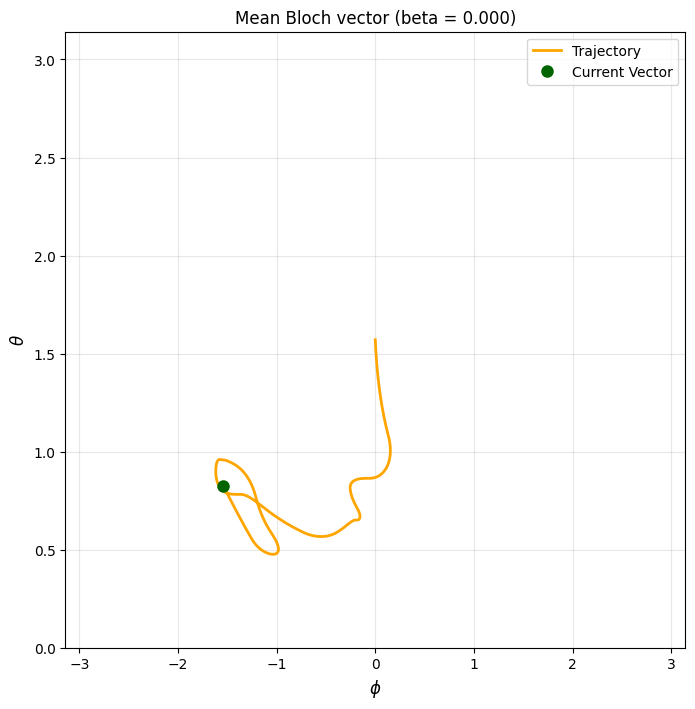

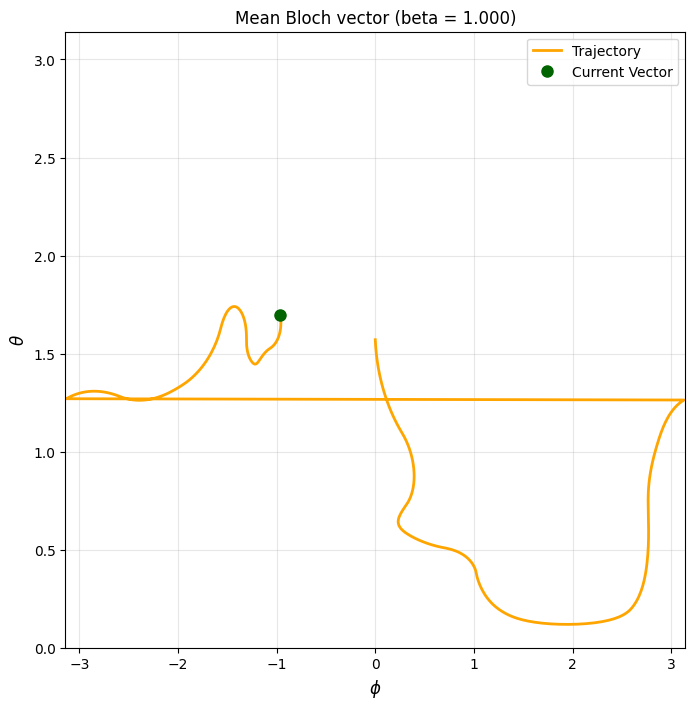

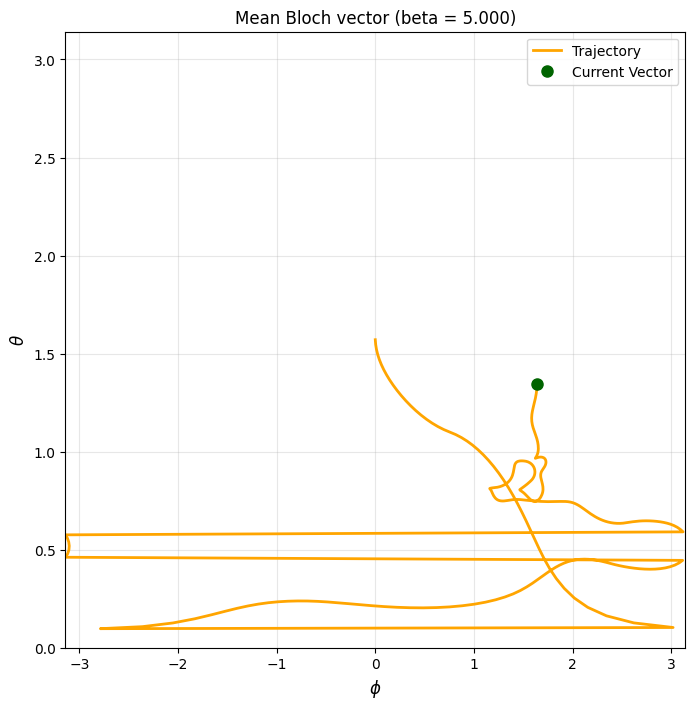

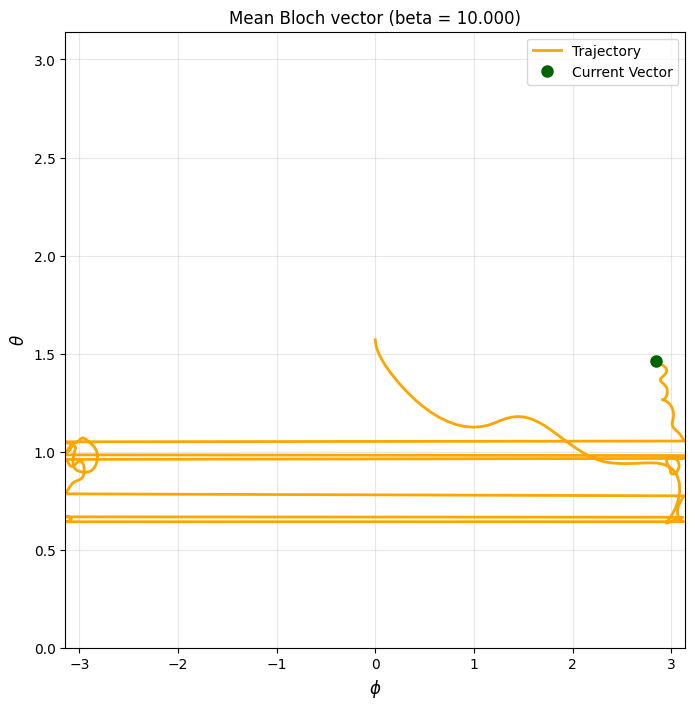

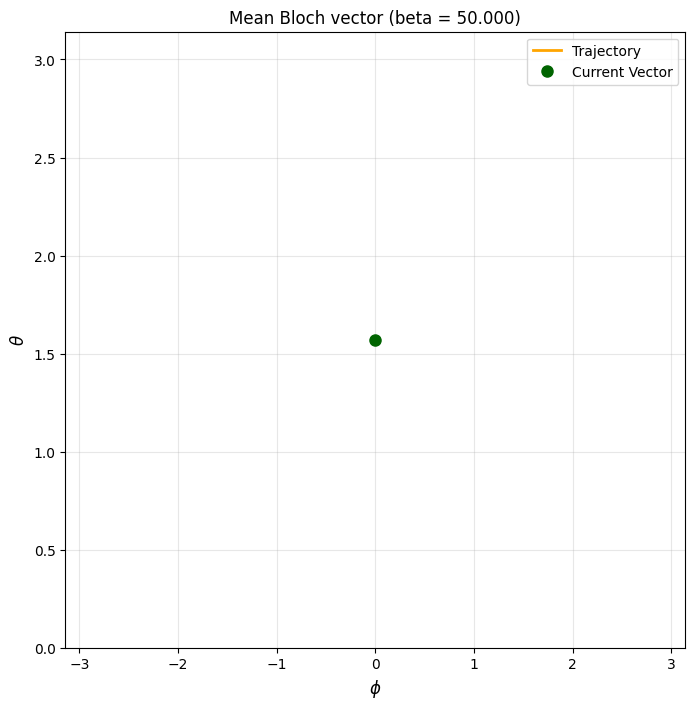

In [10]:
for i in range(runs):
    t = 50
    r = mean_norm_array[i][0::t]
    x = mean_n_array[i][:,0][0::t]
    y = mean_n_array[i][:,1][0::t]
    z = mean_n_array[i][:,2][0::t]
    theta = np.arccos(z / r)
    phi = np.arctan2(y, x)

    fig, ax = plt.subplots(figsize=(8, 8))

    ax.set_xlim([-np.pi, np.pi])
    ax.set_ylim([0, np.pi])
    ax.set_xlabel(r"$\phi$", fontsize=12)
    ax.set_ylabel(r"$\theta$", fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.set_title(f'Mean Bloch vector (beta = {beta_array[i]:.3f})')

    # Trajectory + current point
    traj, = ax.plot([], [], lw=2, color='orange', label='Trajectory')
    point, = ax.plot([], [], 'o', color='darkgreen', markersize=8, label='Current Vector')

    ax.legend(loc='upper right')

    def update(frame):
        traj.set_data(phi[:frame], theta[:frame])
        point.set_data([phi[frame]], [theta[frame]])
        return traj, point

    ani = animation.FuncAnimation(fig, update, frames=len(phi), interval=40)
    ani.save(f'mean_theta_phi_beta={beta_array[i]}.mp4', writer='ffmpeg', fps=30, dpi=100)
